<a href="https://colab.research.google.com/github/martynalacha/Computational-Intelligence-Labs/blob/main/Linear_Classifiers_and_Perceptron_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Separability and Training Set Size Analysis

The following section explores the fundamentals of linear classification by analyzing how the volume of available training data influences the determination of an optimal decision boundary.

**Implementation Workflow:**
* **Synthetic Data Generation:** Creating a dataset of 200 points distributed between two classes ($K_1$ and $K_2$) based on distinct Gaussian distributions.
* **Incremental Training:** Calculating the linear separating hyperplane for training sets of varying sizes (5, 10, 20, and 100 samples).
* **Comparative Visualization:** Plotting the calculated boundaries against the test data to observe the stability of the model.
* **Performance Assessment:** Evaluating classification accuracy in relation to the proportion of training versus testing data.

Accuracy for 5 training samples: 0.8513
Weights for 5 training samples: [[0.80225183 1.689325  ]]
Bias for 5 training samples: [0.]
Accuracy for 10 training samples: 0.8474
Weights for 10 training samples: [[1.53400926 3.66100758]]
Bias for 10 training samples: [0.]
Accuracy for 20 training samples: 0.85
Weights for 20 training samples: [[1.053158   2.66925212]]
Bias for 20 training samples: [0.]
Accuracy for 100 training samples: 0.76
Weights for 100 training samples: [[0.34683153 1.90434707]]
Bias for 100 training samples: [1.]


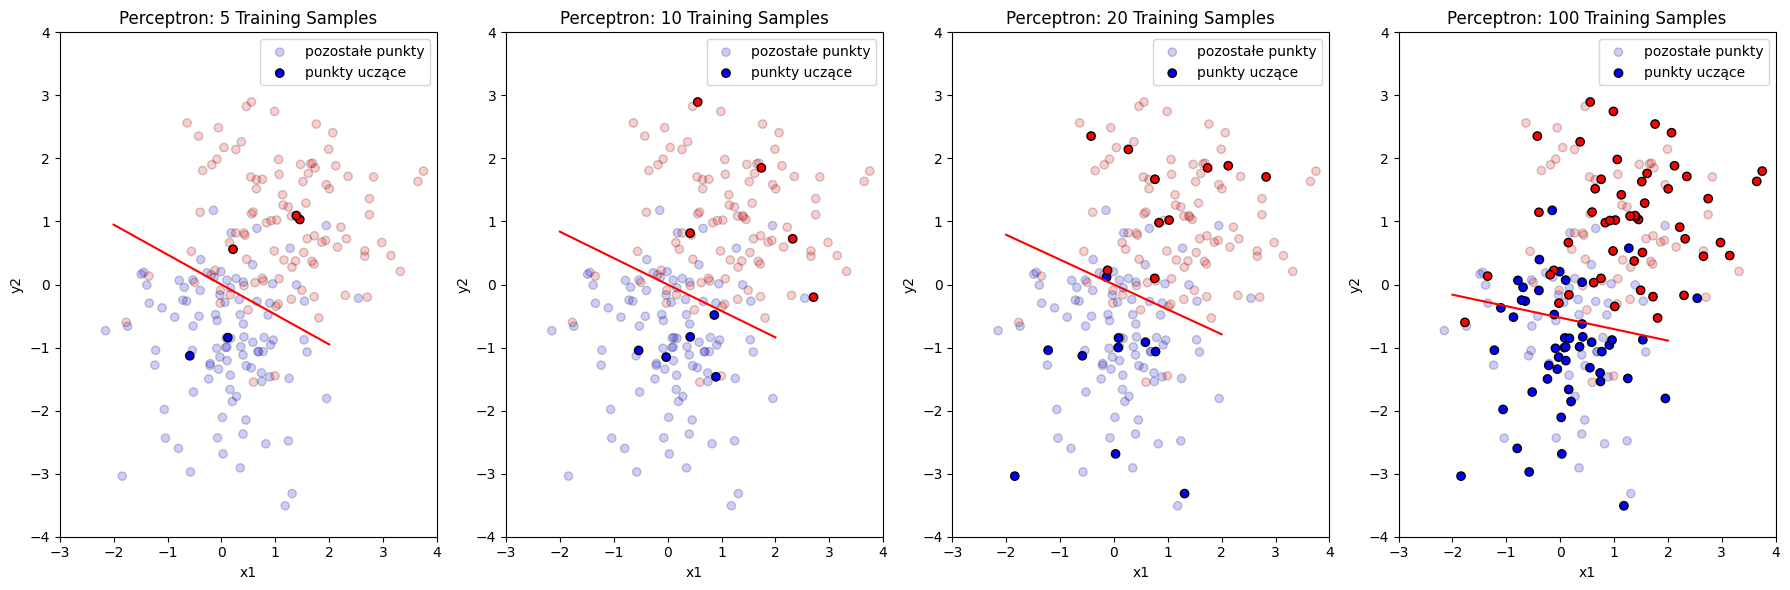

In [4]:
from sklearn.linear_model import Perceptron
import numpy as np
import matplotlib.pyplot as plt

# Function to train the Perceptron and visualize the decision boundary
def plot_result(X_train, Y_train, X_test, Y_test, i, s):

  # Initialize and train the Perceptron model
  # tol: stopping criterion, max_iter: number of epochs
  neuron = Perceptron(tol=1e-3, max_iter = 20)
  neuron.fit(X_train, Y_train)

  # Calculate classification accuracy on the test data
  score = neuron.score(X_test, Y_test)
  print(f"Accuracy for {s} training samples: {round(score, 4)}")
  print(f"Weights for {s} training samples: {neuron.coef_}")
  print(f"Bias for {s} training samples: {neuron.intercept_}")

  # Generate the decision boundary line
  x1 = np.linspace(-2,2,100)
  # Transform the hyperplane formula w1*x1 + w2*x2 + b = 0
  # into the slope-intercept form: x2 = -(w1*x1 + b) / w2
  x2 = -(1./neuron.coef_[0][1])*(neuron.coef_[0][0]*x1+neuron.intercept_[0])
  ax = axes[i]
  ax.plot(x1, x2, '-r')
  ax.scatter(X_test[:,0], X_test[:,1], c=Y_test, cmap='bwr', alpha=0.2, edgecolor='k', label='pozostałe punkty')
  ax.scatter(X_train[:,0], X_train[:,1], c=Y_train, cmap='bwr', edgecolor='k',  label='punkty uczące')

  ax.set_title(f"Perceptron: {s} Training Samples")
  ax.set_xlim(-3, 4)
  ax.set_ylim(-4, 4)
  ax.set_xlabel('x1')
  ax.set_ylabel('y2')
  ax.legend()


# Generate synthetic data points for two classes using normal distributions
# Class 1: Mean [0, -1], Class 2: Mean [1, 1]
K1 = np.random.normal( loc=[0, -1], scale=1, size=(100, 2))
K2 = np.random.normal(loc=[1, 1], scale=1, size=(100, 2))

# Define training set sizes for comparative analysis
samples = [5, 10, 20,100]
X = np.vstack((K1, K2))

# Evaluate model performance across different training set sizes
Y = np.concatenate([np.zeros(100), np.ones(100)])

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Testowanie modelu dla różnych wielkości zbioru uczącego
for i, s in enumerate(samples):

  n_class1 = s // 2
  n_class2 = s - n_class1

  # Randomly select specific indices for the training set
  # Indices 0-99 correspond to Class 1, 100-199 to Class 2
  indices_class1 = np.random.choice(100, n_class1, replace=False)
  indices_class2 = np.random.choice(100, n_class2, replace=False) + 100

  indices = np.concatenate([indices_class1, indices_class2])

  # Construct the training set (X_train, Y_train)
  X_train = X[indices]
  Y_train = Y[indices]

  # Create a boolean mask to designate the remaining points as the test set
  mask = np.ones(X.shape[0], dtype=bool)
  mask[indices] = False
  X_test = X[mask]
  Y_test = Y[mask]

  plot_result(X_train, Y_train, X_test, Y_test, i, s)


plt.tight_layout()
plt.show()







### **Analysis and Conclusions**

* **Impact of Training Set Size:** The decision boundary was least precise with the smallest sample size ($n=5$). While classification effectiveness generally increased with the number of samples, this growth was not always strictly linear across iterations due to the specific characteristics of the randomly selected data.
* **Sensitivity to Random Sampling:** Model performance is highly dependent on the random selection of training points. In small datasets, the inclusion of atypical points causes significant fluctuations in the decision boundary (weights and bias).
* **Variance and Repeatability:** Small training sets are prone to high random error; for $n=5$, accuracy scores fluctuated between **0.74 and 0.90**. Results became significantly more repeatable at $n=100$, stabilizing between **0.82 and 0.89**.
* **Noise Averaging and Generalization:** A larger number of samples effectively "averages out" the noise caused by the overlap of classes $K_1$ and $K_2$. This leads to more stable model parameters and better generalization to unseen test data.
* **Quantity vs. Representativeness:** For the Perceptron model, both the quantity and the representativeness of the data are critical factors for achieving reliable and stable results.

## Perceptron-based Classification of the Iris Dataset

This task focuses on implementing a single-layer perceptron to categorize Iris flower species. The analysis aims to determine the practical limitations of linear classifiers when applied to multi-class biological data and the impact of data partitioning on model reliability.

**Key Technical Steps:**
* **Dataset Acquisition:** Loading the Iris dataset using `sklearn.datasets.load_iris()` and processing morphological features.
* **Model Implementation:** Building a single-layer network using the `Perceptron` algorithm from `sklearn.linear_model`.
* **Data Splitting Strategies:** Evaluating the model across at least **three different train-test split configurations** to measure the variance in classification results.
* **Error Analysis:** Utilizing **Confusion Matrices** over multiple iterations to identify which species pairs are prone to misclassification.

**Analytical Objectives:**
* **Linear Separability Study:** Investigating why certain Iris species (e.g., *Setosa*) are perfectly classified while others (*Versicolor* and *Virginica*) pose a challenge for linear models.
* **Performance Limits:** Determining the maximum achievable accuracy for a single-layer perceptron on this dataset and justifying it through the lens of mathematical linear separability.
* **Split Sensitivity:** Assessing how much the final score depends on the specific distribution of samples between training and testing sets.

In [6]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Load the Iris dataset
iris = load_iris()

# Inspect input data
# Clean feature names by removing unit labels
feature_names = [name.replace(' (cm)', '') for name in iris.feature_names]
# Utilize pandas for a readable table display
irisDF = pd.DataFrame(iris.data, columns=feature_names)
irisDF['target'] = iris.target
irisDF['target_name'] = irisDF['target'].apply(lambda x: iris.target_names[x])
print("Input Data Overview:")
print(irisDF.head())

# Prepare data for the model
X = np.array(iris.data)
Y = np.array(iris.target)

# Feature standardization - scaling dimensions to a common range
scaler = StandardScaler()
X = scaler.fit_transform(X)
print("\nVerifying Input Data Standardization:")
print(f"Means:{ X.mean(axis=0)}")# Should be close to 0
print(f"Standard Deviations: {X.std(axis=0)}")# Should be 1

# Define different split proportions for the training set
precent = [0.7, 0.75, 0.8, 0.85, 0.9]
confusion_matrixIris = None

print("\nAccuracy")
for prec in precent:

  # Split into training and testing sets using stratified sampling to preserve class balance
  X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size = prec, stratify=Y)
  # Initialize and train the single-layer perceptron
  perceptron_layer = Perceptron(tol=1e-3, max_iter=20)
  perceptron_layer.fit(X_train, y_train)

  # Calculate accuracy for both training and testing phases
  train_score = perceptron_layer.score(X_train, y_train)
  test_score = perceptron_layer.score(X_test, y_test)
  print(f"Split {prec} -> Train Acc: {round(train_score, 3)} | Test Acc: {round(test_score, 3)}")

  # Capture the confusion matrix specifically for the 80/20 split
  if prec == 0.8:
    # print(perceptron_layer.coef_)
    # print(f"Bias {perceptron_layer.intercept_}")
    confusion_matrix_iris = confusion_matrix(y_test, perceptron_layer.predict(X_test))


print(f"\nConfusion matrix:\n {confusion_matrix_iris}")





Input Data Overview:
   sepal length  sepal width  petal length  petal width  target target_name
0           5.1          3.5           1.4          0.2       0      setosa
1           4.9          3.0           1.4          0.2       0      setosa
2           4.7          3.2           1.3          0.2       0      setosa
3           4.6          3.1           1.5          0.2       0      setosa
4           5.0          3.6           1.4          0.2       0      setosa

Verifying Input Data Standardization:
Means:[-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Standard Deviations: [1. 1. 1. 1.]

Accuracy
Split 0.7 -> Train Acc: 0.924 | Test Acc: 0.867
Split 0.75 -> Train Acc: 0.902 | Test Acc: 0.868
Split 0.8 -> Train Acc: 0.867 | Test Acc: 0.867
Split 0.85 -> Train Acc: 0.921 | Test Acc: 0.957
Split 0.9 -> Train Acc: 0.844 | Test Acc: 0.8

Confusion matrix:
 [[10  0  0]
 [ 0  6  4]
 [ 0  0 10]]


### **Analysis and Conclusions (Iris Dataset)**

* **Linear Separability and Model Limits:** The Perceptron is a linear classifier, meaning its effectiveness is strictly limited by the geometric features of the data.
    * **Iris Setosa** is fully linearly separable, allowing the model to consistently achieve 100% accuracy.
    * **Iris Versicolor and Virginica** overlap in the feature space, making them linearly inseparable. This creates a mathematical barrier that a single-layer perceptron cannot overcome.
* **Accuracy Fluctuations:** Experimental data shows that results are highly unstable, with scores jumping drastically (e.g., from **0.608** to **0.933**). High accuracy in this model is often a result of a "lucky" random data split rather than the actual strength of the linear model.
* **Training Accuracy Insight:** Even on the training set, the model rarely reaches 100% accuracy. This serves as definitive proof that the boundary between Versicolor and Virginica is not a straight line; the model cannot perfectly classify the very data it is learning from.
* **Impact of Test Set Size on Stability:** The size of the test set directly affects result "noise."
    * In a **90/10 split** (15 test samples), a single misclassified flower causes a **~7% drop** in accuracy, making the result volatile and less reliable.
    * A larger test set (e.g., **70/30**) provides a more stable and realistic representation of the perceptron’s true capabilities.
* **Data Volume vs. Representativeness:** Increasing the training set size does not guarantee a steady increase in accuracy. At this scale (150 samples), the **representativeness** of the data is more critical than the quantity. A larger training set cannot compensate for atypical "boundary" samples present in a small test set.
* **Final Verdict:** A single-layer perceptron is insufficient for stable, high accuracy on the Iris dataset. To eliminate errors caused by the non-linear boundary between species, more complex non-linear models (such as Multi-Layer Perceptrons) would be required.

## Impact of Data Splitting and Training Duration (Epochs)

This final section examines how external factors, such as the number of training iterations, affect model convergence and final accuracy.

**The analysis includes:**
* **Splitting Sensitivity:** Testing model performance across at least three different data-splitting strategies to measure result variance.
* **Epoch Influence Study:** Analyzing how the number of training epochs (starting from minimal values) impacts classification correctness.
* **Convergence Control:** Disabling early stopping criteria (adjusting `tol` and `early_stopping` parameters) to observe the full learning process or tracking the `n_iter_` attribute.
* **Performance Visualization:** Plotting the relationship between the number of epochs and average classification accuracy to identify the point of optimal convergence.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


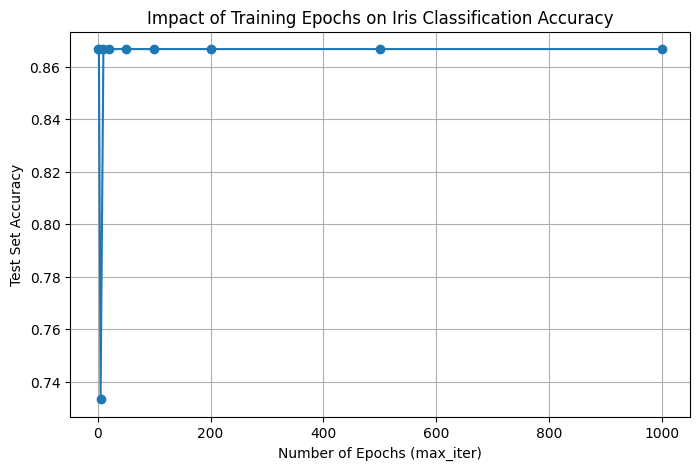

In [7]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data
Y = iris.target

# Feature standardization to ensure all dimensions are on a common scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into training and testing sets (80% training data)
# Using stratification to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, train_size=0.8, stratify=Y, random_state=42
)
# Defined list of epochs (max_iter) for evaluation
epoch_list = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

test_accuracies = []

for epochs in epoch_list:
    # Initialize Perceptron with a fixed number of iterations (max_iter)
    # Automatic stopping criteria (tol and early_stopping) are minimized or disabled
    # to force the model to complete the specified number of epochs
    perceptron_layer = Perceptron(
        max_iter=epochs,
        tol=1e-6,
        early_stopping=False,
        random_state=42
    )
    # Model training and accuracy verification
    perceptron_layer.fit(X_train, y_train)
    y_pred = perceptron_layer.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_accuracies.append(acc)

# Plotting the results
plt.figure(figsize=(8,5))
plt.plot(epoch_list, test_accuracies, marker='o')
plt.title("Impact of Training Epochs on Iris Classification Accuracy")
plt.xlabel("Number of Epochs (max_iter)")
plt.ylabel("Test Set Accuracy")
plt.grid(True)
plt.show()

### **Analysis and Conclusions**

* **Rapid Convergence:** Accuracy increases rapidly within the first 5–10 epochs and stabilizes around the 20th iteration (approx. 86%).
* **Underfitting Signals:** At low epoch counts (1–5), `ConvergenceWarning` messages appear, indicating that the iteration limit was too low for weights to stabilize.
* **Linearity Limit:** Increasing iterations beyond 20 (up to 1000) provides no further improvement. This confirms that the model has reached the absolute limit of linear classification for the Iris dataset.
* **Efficiency:** For simple linear models, the initial training cycles are the most critical. Once convergence is reached, further training is computationally pointless due to the non-linear overlap between *Versicolor* and *Virginica*.